# Short-Gamma — **Type 1 only** — sandbox

Pipeline:
1. **Precompute** the markout bundle (4 ridge combos + score-bucket edges + per-bucket
   percentile tables, one per `{up,down} × {120min, 30min}`) on the **train** split and
   pickle it to `MARKOUT_DIR`.
2. **Run** `ShortGammaT1` through `BirdsEye` (it reads the bundle, recomputes the score
   live from the feed via the *shared* feature module, and trades Type 1 only).
3. **Report**: pair-PnL attribution, enter/exit condition stats, time-in-market, and an
   interactive strikes-vs-time plot — all reconstructed from the returned tradelog.

Nothing in `engine/` is modified. The strategy + helpers are the new files under
`strategies/`. Greeks are skipped (SPY OPRA carries none).

## 1. Config

In [10]:
import os, sys, json, pickle, math
import numpy as np, pandas as pd

# strategies/ must be importable so the shared feature/markout helpers resolve the
# same way the strategy imports them.
sys.path.insert(0, os.path.abspath("strategies"))

from engine import BirdsEye
from data import get_manifest_files
from config import get_column_map
from builder import build_features, build_targets, merge_features_targets

from short_gamma_features import make_features, FEATURE_NAMES, FEED_FIELDS, MAX_LOOKBACK
from short_gamma_markout  import build_bundle, model_key, BUNDLE_NAME, load_bundle, SignalEngine
from short_gamma_t1       import ShortGammaT1

# ---- paths / knobs -------------------------------------------------------------
INDEX       = "SPY"
MANIFEST    = "../../manifest.json"            # adjust to your checkout
MARKOUT_DIR = "../../Markout_Analysis/Intern-Project"          # <-- your markout directory variable
os.makedirs(MARKOUT_DIR, exist_ok=True)

N_JOBS      = 10
N_BUCKETS   = 8                                 # score buckets (= notebook N_QUANTILES)
PCT_LEVELS  = [5, 25, 50, 75, 95]               # strat uses p50 & p75
FWD_LONG    = 120 * 60                          # 7200s — entry (UR120/DR120)
FWD_SHORT   = 30 * 60                           # 1800s — exit / TP-gate (UR30/DR30)
RIDGE_ALPHA = 1.0

# economics (keep these in sync between fit, run, and TP/SL sizing)
LOT_SIZE       = 100
MARGIN_PER_LOT = 10000.0

column_map  = get_column_map(INDEX)
train_files = get_manifest_files(INDEX, "train", manifest_path=MANIFEST)
test_files  = get_manifest_files(INDEX, "test",  manifest_path=MANIFEST)
print(f"{INDEX}: train={len(train_files)}  test={len(test_files)}  feat={FEATURE_NAMES}")

SPY: train=279  test=119  feat=['rv_900s', 'rolling_straddle_std_10min', 'vwap_gap_abs_bps', 'abs_long_vol_accel_600_1800', 'bps_below_high_900s']


## 2. Precompute the markout bundle

The four features feeding the score are built through `make_features()` — the **same**
functions the live strategy uses — so the fitted weights apply unchanged at runtime.
Targets are the up/down forward excursions at both horizons.

In [2]:
from features import Feature
from targets  import Target

# wrap the shared feature fns into the research Feature type (parity by construction)
FEATURES = [Feature(name=n, fn=fn, lookback=lb, columns=cols)
            for (n, fn, lb, cols) in make_features()]

def up_range_bips():
    def _fn(arrays, ts, fwd):
        spot = arrays["spot"]; idx = ts[:, None] + np.arange(0, fwd + 1)
        return (np.max(spot[idx], axis=1) - spot[ts]) / spot[ts] * 1e4
    return Target(name="up_range_bips", fn=_fn, columns=["spot"])

def down_range_bips():
    def _fn(arrays, ts, fwd):
        spot = arrays["spot"]; idx = ts[:, None] + np.arange(0, fwd + 1)
        return (spot[ts] - np.min(spot[idx], axis=1)) / spot[ts] * 1e4
    return Target(name="down_range_bips", fn=_fn, columns=["spot"])

TARGETS = [up_range_bips(), down_range_bips()]

df_feat = build_features(train_files, FEATURES, column_map, stride=1, n_jobs=N_JOBS, verbose=False)
df_tgt  = build_targets (train_files, TARGETS, [FWD_SHORT, FWD_LONG], column_map,
                         stride=1, n_jobs=N_JOBS, verbose=False)
df_obs  = merge_features_targets(df_feat, df_tgt)
print("train obs:", df_obs.shape, "| cols:", [c for c in df_obs.columns if "range_bips" in c])

Merged: 2,967,019 obs | 5 feature col(s) | 4 target col(s)
train obs: (2967019, 11) | cols: ['up_range_bips_1800', 'up_range_bips_7200', 'down_range_bips_1800', 'down_range_bips_7200']


In [3]:
from sklearn.linear_model import Ridge

def fit_one(df, feat_cols, target_col, n_buckets, pct_levels, alpha):
    d  = df[feat_cols + [target_col]].dropna()
    mu = d[feat_cols].mean(); sd = d[feat_cols].std().replace(0, 1.0)
    Xz = (d[feat_cols] - mu) / sd
    rg = Ridge(alpha=alpha).fit(Xz, d[target_col])
    score  = rg.predict(Xz)
    edges  = np.quantile(score, [k / n_buckets for k in range(1, n_buckets)])
    bucket = np.clip(np.searchsorted(edges, score, side="right"), 0, n_buckets - 1)
    y      = d[target_col].to_numpy(float)
    table  = np.vstack([
        np.percentile(y[bucket == b], pct_levels) if (bucket == b).any()
        else np.full(len(pct_levels), np.nan)
        for b in range(n_buckets)])
    return dict(mu=mu.to_numpy(float), sd=sd.to_numpy(float),
                coef=rg.coef_.astype(float), intercept=float(rg.intercept_),
                edges=edges.astype(float), pct_table=table.astype(float))

models = {}
for side in ("up", "down"):
    for h in (FWD_LONG, FWD_SHORT):
        tcol = f"{side}_range_bips_{h}"
        models[model_key(side, h)] = fit_one(df_obs, FEATURE_NAMES, tcol,
                                             N_BUCKETS, PCT_LEVELS, RIDGE_ALPHA)
        m = models[model_key(side, h)]
        print(f"{side:<4} {h//60:>3}min | p50 by bucket:",
              np.round(m["pct_table"][:, PCT_LEVELS.index(50)], 1))

bundle = build_bundle(models, dict(index=INDEX, fwd_long=FWD_LONG, fwd_short=FWD_SHORT,
                                   n_train_days=len(train_files), ridge_alpha=RIDGE_ALPHA),
                      N_BUCKETS, PCT_LEVELS)
with open(os.path.join(MARKOUT_DIR, BUNDLE_NAME), "wb") as fh:
    pickle.dump(bundle, fh)
print("saved bundle ->", os.path.join(MARKOUT_DIR, BUNDLE_NAME))

up   120min | p50 by bucket: [10.8 11.8 13.2 14.9 16.7 20.6 26.9 36.2]
up    30min | p50 by bucket: [ 4.9  5.8  6.6  7.8  9.7 11.1 14.  21.7]
down 120min | p50 by bucket: [10.  13.4 14.8 15.9 20.1 23.9 25.8 37.6]
down  30min | p50 by bucket: [ 5.   6.7  8.   7.8  9.1 11.7 13.7 21.1]
saved bundle -> ../../Markout_Analysis/Intern-Project/short_gamma_markout.pkl


### 2b. Parity check (optional)
Confirm the bundle's live evaluator reproduces the training score on one day, i.e. the
feed→features→score→bucket path matches the fit path.

In [4]:
from engine import Feed
se = SignalEngine(load_bundle(MARKOUT_DIR))
_feed = Feed.from_raw(train_files[0]["path"], INDEX, fields=FEED_FIELDS)
se.prepare(_feed)
print("min_history:", se.min_history)
print("sample active row:", {k: round(v, 2)
      for k, v in se.row(min(len(_feed) - 1, MAX_LOOKBACK + 500)).items()
      if k.startswith(("UR", "DR"))})

min_history: 1801
sample active row: {'UR120_p50': 16.66, 'UR120_p75': 27.46, 'DR120_p50': 23.89, 'DR120_p75': 44.04, 'UR30_p50': 11.14, 'UR30_p75': 18.39, 'DR30_p50': 11.71, 'DR30_p75': 21.12}


## 3. Run the strategy

`max_lots=2` (the Type-1 cap per side). `tp_pct`/`sl_pct` default to `None` (off) — set
them to a fraction of pair margin to enable. The strat squares off `EOD_BUFFER_SEC` before
the close, so the engine's force-square is just a backstop.

In [11]:
be = BirdsEye(
    data_dir          = None,                  # manifest-driven
    strategy_cls      = ShortGammaT1,
    index             = INDEX,
    strategy_kwargs   = dict(markout_dir=MARKOUT_DIR, margin_per_lot=MARGIN_PER_LOT,
                             tp_pct=None, sl_pct=None),
    fields            = FEED_FIELDS,
    lot_size          = LOT_SIZE,
    margin_per_lot    = MARGIN_PER_LOT,
    max_lots          = 2,
    cost_kwargs       = dict(txn_cost_per_lot=0.0),
    collect_perseclog = True,
    n_workers         = 4,
)
res = be.run()
res.summary.head()

,fills,gross($),costs($),net($)
day,,,,
20240102,8,-18.0,4.0,-22.0
20240104,8,42.0,5.0,37.0
20240105,0,0.0,0.0,0.0
20240109,0,0.0,0.0,0.0
20240110,16,-86.0,9.0,-95.0


{'avg_day': 2.3682,
 'avg_hold_time': 5656.5367,
 'avg_loss': -85.6842,
 'avg_win': 61.5556,
 'best_day': 306.0,
 'cagr_gross': 8.6562,
 'cagr_net': 2.984,
 'calmar_gross': 1.4156,
 'calmar_net': 0.3976,
 'churn': 0.7906,
 'maxDD_gross': 6.115,
 'maxDD_net': 7.505,
 'n_days': 277,
 'n_fills': 1752,
 'pct_neg_days': 0.2058,
 'pct_pos_days': 0.3249,
 'time_in_market': 0.2258,
 'total_costs': 1247.0,
 'total_pnl': 656.0,
 'worst_day': -436.0}


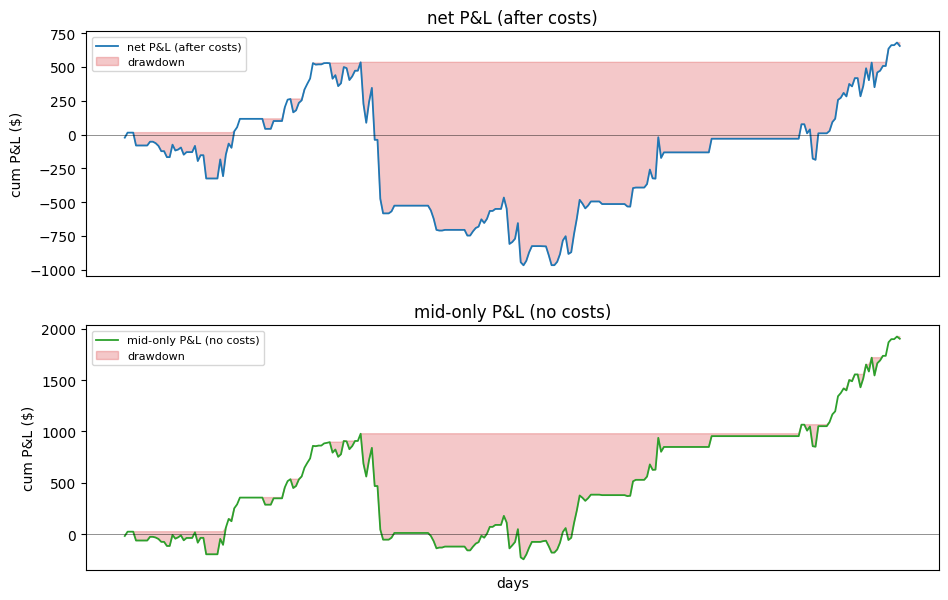

In [12]:
import pprint; pprint.pprint(res.stats())
try:
    from engine.plots import plot_equity; plot_equity(res)
except Exception:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(11,3)); plt.plot(res.all_curve); plt.title("equity"); plt.show()

## 4. Reports (reconstructed from the tradelog)

Every order is stamped with `signal` + a JSON `note` carrying the Type-1 `pair` ids, so
entries and exits match exactly. `Fill.ts` is seconds-from-open.

In [13]:
def reconstruct_pairs(tradelog):
    """One row per Type-1 pair: entry/exit ts, strikes, fill prices, per-leg & pair PnL,
    and the exit condition. Uses the JSON notes (pair ids) + per-strike fills."""
    fills = sorted(tradelog.fills, key=lambda f: f.ts)
    pairs = {}                                   # pair_id -> record
    # index close fills by (ts, strike, opt) for price lookup
    for f in fills:
        try: note = json.loads(f.reason.note)
        except Exception: note = {}
        if note.get("inst") != "t1":
            continue
        if f.reason.signal == "t1_entry" and f.action == "SELL":
            # entry order: this fill is one side; attach its price to every pair in note
            for pid in note.get("pairs", []):
                rec = pairs.setdefault(pid, dict(pair_id=pid, batch=note.get("batch"),
                       entry_ts=f.ts, ce_k=note.get("ce"), pe_k=note.get("pe"),
                       ce_entry=None, pe_entry=None, ce_exit=None, pe_exit=None,
                       exit_ts=None, exit_reason=None))
                if f.opt_type == "CE": rec["ce_entry"] = f.fill_price
                else:                  rec["pe_entry"] = f.fill_price
        elif f.action == "BUY":        # a close (breach/tp/sl/eod)
            for pid in note.get("pairs", []):
                rec = pairs.get(pid)
                if rec is None:        # fallback: engine EOD with no note
                    continue
                if f.opt_type == "CE": rec["ce_exit"] = f.fill_price
                else:                  rec["pe_exit"] = f.fill_price
                rec["exit_ts"]     = f.ts
                rec["exit_reason"] = f.reason.signal or "eod_engine"
    rows = []
    for r in pairs.values():
        cep = (r["ce_entry"] - r["ce_exit"]) if None not in (r["ce_entry"], r["ce_exit"]) else np.nan
        pep = (r["pe_entry"] - r["pe_exit"]) if None not in (r["pe_entry"], r["pe_exit"]) else np.nan
        rows.append({**r, "ce_pnl_pts": cep, "pe_pnl_pts": pep, "pair_pnl_pts": cep + pep})
    return pd.DataFrame(rows)

frames = []
for day in res.days:
    df = reconstruct_pairs(res.tradelogs[day])
    if not df.empty:
        df.insert(0, "day", day); frames.append(df)
pairs_df = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
pairs_df["pair_pnl_$"] = pairs_df["pair_pnl_pts"] * LOT_SIZE
print(f"{len(pairs_df)} pairs | total pair PnL (pts): {pairs_df['pair_pnl_pts'].sum():.1f}")
pairs_df.head(12)

438 pairs | total pair PnL (pts): 19.8


,day,pair_id,batch,entry_ts,ce_k,pe_k,ce_entry,pe_entry,ce_exit,pe_exit,exit_ts,exit_reason,ce_pnl_pts,pe_pnl_pts,pair_pnl_pts,pair_pnl_$
0,20240102,0,0,17969,472.0,471.0,0.365,0.145,0.145,0.455,19438,t1_breach_half,0.220,-0.31,-0.090,-9.0
1,20240102,1,0,17969,472.0,471.0,0.365,0.145,0.145,0.455,19441,t1_breach_half,0.220,-0.31,-0.090,-9.0
2,20240104,0,0,14601,469.0,468.0,0.720,0.115,0.480,0.145,16406,t1_breach_half,0.240,-0.03,0.210,21.0
3,20240104,1,0,14601,469.0,468.0,0.720,0.115,0.485,0.145,16410,t1_breach_half,0.235,-0.03,0.205,20.5
4,20240110,0,0,5978,475.0,474.0,0.795,0.295,0.880,0.135,12977,t1_breach_half,-0.085,0.16,0.075,7.5
5,20240110,1,0,5978,475.0,474.0,0.795,0.295,0.860,0.135,12979,t1_breach_half,-0.065,0.16,0.095,9.5
6,20240110,2,1,15635,476.0,475.0,0.325,0.215,0.915,0.125,17043,t1_breach_half,-0.590,0.09,-0.500,-50.0
7,20240110,3,1,15635,476.0,475.0,0.325,0.215,0.935,0.125,17045,t1_breach_half,-0.610,0.09,-0.520,-52.0
8,20240122,0,0,10937,484.0,483.0,0.665,0.295,0.395,0.435,13069,t1_breach_half,0.270,-0.14,0.130,13.0
9,20240122,1,0,10937,484.0,483.0,0.665,0.295,0.255,0.585,14249,t1_breach_half,0.410,-0.29,0.120,12.0


In [18]:
pairs_df.to_csv("pairs_df.csv")

In [14]:
# exit reason breakdown + per-leg attribution
if not pairs_df.empty:
    by = pairs_df.groupby("exit_reason").agg(
        n=("pair_id", "count"),
        pair_pnl_pts=("pair_pnl_pts", "sum"),
        ce_pnl_pts=("ce_pnl_pts", "sum"),
        pe_pnl_pts=("pe_pnl_pts", "sum"))
    display(by.round(1))

,n,pair_pnl_pts,ce_pnl_pts,pe_pnl_pts
exit_reason,,,,
t1_breach_full,2,-0.7,-1.5,0.8
t1_breach_half,252,4.4,25.4,-21.0
t1_eod,184,16.0,-18.5,34.5


In [15]:
# enter / exit CONDITION stats — the alpha_* values stamped on each order
tl = res.tradelog
cond_cols = [c for c in tl.columns if c.startswith("alpha_")
             and any(k in c for k in ("UR120", "DR120", "UR30", "DR30"))]
print("orders by signal:")
display(tl.groupby("signal").size().rename("n_fills"))
print("\ncondition values at fire (mean) by signal:")
display(tl.groupby("signal")[cond_cols].mean().round(2))

orders by signal:


signal
t1_breach_full      4
t1_breach_half    504
t1_entry          876
t1_eod            368
Name: n_fills, dtype: int64


condition values at fire (mean) by signal:


,alpha_UR120_p50,alpha_UR120_p75,alpha_score_UR120,alpha_bucket_UR120,alpha_DR120_p50,alpha_DR120_p75,alpha_score_DR120,alpha_bucket_DR120,alpha_UR30_p50,alpha_UR30_p75,alpha_score_UR30,alpha_bucket_UR30,alpha_DR30_p50,alpha_DR30_p75,alpha_score_DR30,alpha_bucket_DR30
signal,,,,,,,,,,,,,,,,
t1_breach_full,26.91,45.57,29.43,7.00,37.59,69.12,42.59,8.00,13.97,23.19,17.39,7.00,13.69,24.83,19.14,7.00
t1_breach_half,14.15,23.13,17.80,3.53,15.61,30.15,20.37,3.61,7.90,13.77,9.22,4.05,7.96,13.99,10.18,3.66
t1_entry,11.33,18.50,13.78,1.52,10.00,18.56,14.29,1.00,5.48,9.24,6.79,1.64,5.77,10.38,7.23,1.47
t1_eod,11.35,18.60,13.57,1.50,11.50,21.58,14.21,1.48,5.30,9.12,6.42,1.46,5.81,10.46,7.19,1.52


In [16]:
# time-in-market (Type 1 == total here)
st = res.stats()
print("time_in_market:", st.get("time_in_market"), " avg_hold_time:", st.get("avg_hold_time"))

time_in_market: 0.2258  avg_hold_time: 5656.5367


### Interactive: which strikes was I short, when (per day)
Horizontal segments = a leg's life (entry→exit) at its strike; spot overlaid.

In [22]:
import plotly.graph_objects as go

def plot_strikes(day):
    df = reconstruct_pairs(res.tradelogs[day])
    ps = res.perseclog(day)
    fig = go.Figure()
    if "timestamp" in ps and "spot" in ps:
        fig.add_trace(go.Scatter(x=ps["timestamp"], y=ps["spot"], name="spot",
                                 line=dict(color="black", width=1)))
    for _, r in df.iterrows():
        x0, x1 = r["entry_ts"], (r["exit_ts"] if pd.notna(r["exit_ts"]) else ps["timestamp"].max())
        for k, opt, col in ((r["ce_k"], "CE", "crimson"), (r["pe_k"], "PE", "royalblue")):
            fig.add_trace(go.Scatter(
                x=[x0, x1], y=[k, k], mode="lines",
                line=dict(color=col, width=4), opacity=0.6,
                name=f"{opt} short", legendgroup=opt, showlegend=False,
                hovertext=f"pair {r['pair_id']} {opt}@{k} exit={r['exit_reason']}"))
    fig.update_layout(title=f"Type-1 short strikes — {day}",
                      xaxis_title="seconds from open", yaxis_title="strike",
                      height=480, template="plotly_white")
    fig.show()

plot_strikes(res.days[4])

### Delta / gamma
SPY OPRA carries no greeks, so per the spec these are skipped. On an index that supplies
`delta`/`gamma` columns, load them via `fields=(... , "ce_delta","pe_delta","ce_gamma","pe_gamma")`
and sum `greek × signed_lots` per second from the tradelog to chart book delta/gamma.